<a href="https://colab.research.google.com/github/vgayathri13/VRSU/blob/main/VRSU_SemanticAndInstanceSegmentation9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import cv2
import gc

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from google.colab import files

# --------- Clear memory ---------
tf.keras.backend.clear_session()
gc.collect()

# --------- Load Dataset (only for training) ---------
(ds_train, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = ds_info.features["label"].num_classes
IMG_SIZE = 128
BATCH_SIZE = 16

# --------- Preprocessing function ---------
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    return image, label

train_ds = ds_train.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --------- Load MobileNetV2 (Pretrained) ---------
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False   # Freeze feature extractor

# --------- Add Classification Head ---------
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation="relu")(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

# --------- Compile ---------
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --------- Train Model ---------
model.fit(train_ds, epochs=3)

# --------- Evaluate (optional) ---------
loss, acc = model.evaluate(test_ds)
print("Validation Accuracy:", acc)


Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 57s 252ms/step - accuracy: 0.6406 - loss: 1.3240
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 38s 208ms/step - accuracy: 0.9046 - loss: 0.3134
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 39s 213ms/step - accuracy: 0.9684 - loss: 0.1452
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 218ms/step - accuracy: 0.8546 - loss: 0.5118
Validation Accuracy: 0.854619562625885


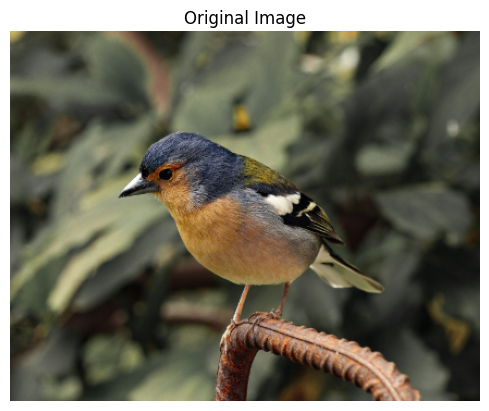

Running Semantic Segmentation...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:11<00:00, 21.9MB/s]


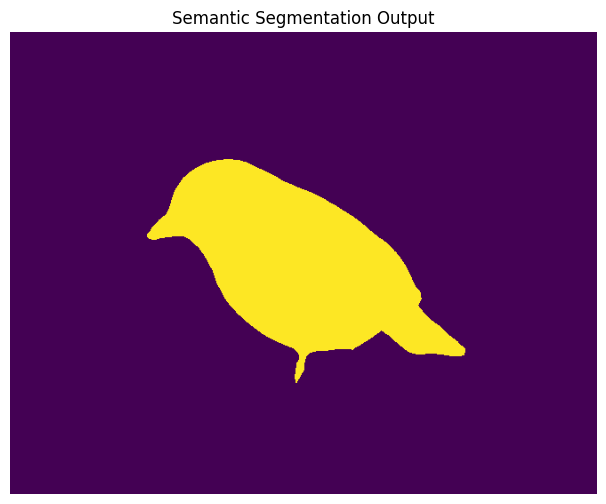

Running Instance Segmentation...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 104MB/s] 


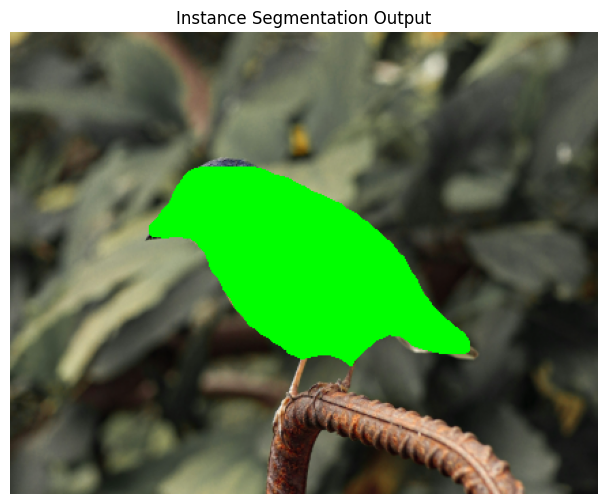

In [14]:
!pip install torch torchvision matplotlib pillow opencv-python

import torch
import torchvision.transforms as T
import torchvision.models as models
import torchvision.models.detection as detection
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2


image_path = "/content/bird1 (1).png"
image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

# PART 1: SEMANTIC SEGMENTATION (DeepLabV3)

print("Running Semantic Segmentation...")

semantic_model = models.segmentation.deeplabv3_resnet101(pretrained=True)
semantic_model.eval()

transform = T.Compose([
    T.Resize(520),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225])
])

input_tensor = transform(image).unsqueeze(0)

with torch.no_grad():
    semantic_output = semantic_model(input_tensor)['out'][0]

semantic_mask = semantic_output.argmax(0).byte().cpu().numpy()

plt.figure(figsize=(8,6))
plt.imshow(semantic_mask)
plt.title("Semantic Segmentation Output")
plt.axis("off")
plt.show()


# PART 2: INSTANCE SEGMENTATION (Mask R-CNN)

print("Running Instance Segmentation...")

instance_model = detection.maskrcnn_resnet50_fpn(pretrained=True)
instance_model.eval()

transform = T.ToTensor()
img_tensor = transform(image)

with torch.no_grad():
    predictions = instance_model([img_tensor])


# Convert to OpenCV format
image_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

# Apply masks
for i in range(len(predictions[0]['masks'])):

    score = predictions[0]['scores'][i]

    if score > 0.5:

        mask = predictions[0]['masks'][i,0].mul(255).byte().cpu().numpy()

        image_cv[mask > 127] = [0,255,0]


plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB))
plt.title("Instance Segmentation Output")
plt.axis("off")
plt.show()
